# Lab 11 — Self-Supervised Learning

Credits:
- the notebook is originally created by Daniel Kałuża
- modified and extended by Sebastian Stawicki and Piotr Biczyk
- revised and annotated edition

## Why this lab

Labels are expensive; raw data is cheap. In most engineering settings you can collect orders of magnitude more unlabeled examples than you can ever annotate. **Self-supervised learning (SSL)** is the toolkit that turns that unlabeled pile into a head start: you invent a "pretext" task whose labels are generated automatically from the data itself, train a network to solve it, and then transfer the learned representation to the real task you actually care about - usually with far fewer labels than training from scratch would need.

In this lab you will implement **RotNet** (Gidaris, Singh, Komodakis, *Unsupervised Representation Learning by Predicting Image Rotations*, ICLR 2018, [arXiv:1803.07728](https://arxiv.org/abs/1803.07728)). The pretext task is to predict by how much an image has been rotated (0°, 90°, 180°, 270°). To solve it, the network has no choice but to learn what objects look like and which way is "up". You will then re-use the network's backbone for Fashion-MNIST classification with only **2% of the labels**, and compare it to a network trained on the same 2% from random initialization. In other words - after learning the representation, we will use the trained weights as a starting point for the actual classification task. We will then compare the results to those of a network trained from scratch. The expected story: the pretrained model wins, and the gap widens as labels get scarcer.


## Sanity check (optional - run once to verify your environment)

The cell below downloads Fashion-MNIST, trains a tiny CNN on 2% of the labels for 5 epochs from scratch, and prints the test balanced accuracy (BAC).

**Purpose:** confirm that PyTorch, the dataset download, and your hardware all work *before* you start writing your own code. It also gives you a rough **target** number to compare your own from-scratch baseline against in Section 2 - if your number is wildly different, double-check your loops.

**Skip this cell** if you'd rather build everything yourself from scratch without anchors.

In [1]:

import random
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import balanced_accuracy_score
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

_SEED = 42
random.seed(_SEED); np.random.seed(_SEED)
torch.manual_seed(_SEED); torch.cuda.manual_seed_all(_SEED)
_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", _device)

_tfm = transforms.Compose([transforms.ToTensor(),
                           transforms.Normalize((0.5,), (0.5,))])
_train = datasets.FashionMNIST("./data", train=True,  download=True, transform=_tfm)
_test  = datasets.FashionMNIST("./data", train=False, download=True, transform=_tfm)
_idx = torch.randperm(len(_train),
                      generator=torch.Generator().manual_seed(_SEED))[:int(0.02 * len(_train))]
_sub_loader = DataLoader(Subset(_train, _idx.tolist()), batch_size=64, shuffle=True)
_test_loader = DataLoader(_test, batch_size=256, shuffle=False)

_net = nn.Sequential(
    nn.Conv2d(1, 32, 3), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(),
    nn.Conv2d(32, 64, 3), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(),
    nn.Conv2d(64, 32, 3), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(32, 10),
).to(_device)
_opt = torch.optim.Adam(_net.parameters(), lr=1e-3)
_loss = nn.CrossEntropyLoss()

for _ in range(5):
    _net.train()
    for X, y in _sub_loader:
        X, y = X.to(_device), y.to(_device)
        _opt.zero_grad(); _loss(_net(X), y).backward(); _opt.step()

_net.eval()
_ys, _ps = [], []
with torch.no_grad():
    for X, y in _test_loader:
        X, y = X.to(_device), y.to(_device)
        _ps.extend(_net(X).argmax(1).cpu().numpy()); _ys.extend(y.cpu().numpy())
print(f"Sanity-check baseline BAC after 5 epochs on 2% labels: "
      f"{balanced_accuracy_score(_ys, _ps):.4f}")

# Clean up the underscore-prefixed scratch variables so they don't shadow your work below.
for _name in list(globals()):
    if _name.startswith('_'):
        del globals()[_name]


Device: cuda
Sanity-check baseline BAC after 5 epochs on 2% labels: 0.6438


## 0. Import libraries

In [2]:
import copy
import random
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision

from torchvision import datasets, transforms

# Reproducibility - set ONCE, preferably to a different value than 42, so the random 2% subset and the network init
# stay the same across runs. Without this you cannot tell whether a change  in BAC came from your code change or from a different random subset.
SEED = 23
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Pick a device once and reuse it.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

BATCH_SIZE = 64


Using device: cuda


> **Note — `num_workers`.** Throughout the notebook we use
> `num_workers=2` in the data loaders. On Linux this is fine. **On Windows
> or inside some Jupyter setups it can hang or raise `BrokenPipeError`** —
> if so, set `num_workers=0`.

## 1. Data preparation

We are going to use **Fashion MNIST**. The dataset consists of 60k training images and 10k test images of clothing, 28×28 pixels in grayscale, 10 classes.

Use `FashionMNIST` from `torchvision.datasets` to load the train and test datasets. Use `torchvision.transforms` to transform the original PIL images to float tensors **normalized to `[-1, 1]`**.

E.g.:

```python
transform = transforms.Compose(
    [
        # TODO: add transformations
    ]
)

train = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)
```

> **Hint — normalization to `[-1, 1]`.** `transforms.ToTensor()` maps PIL pixels into `[0, 1]`. To stretch to `[-1, 1]` follow it with `transforms.Normalize((0.5,), (0.5,))` - single channel because the images are grayscale. Symmetric ranges play nicely with `tanh`-like activations and match the conventions used by many SSL papers.

In [3]:
# write your code here
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5), (0.5))])

train = datasets.FashionMNIST(
    root="./data_lab11",
    train=True,
    download=True,
    transform=transform,
)

test = datasets.FashionMNIST(
    root="./data_lab11",
    train=False,
    download=True,
    transform=transform,
)


100%|██████████| 26.4M/26.4M [00:01<00:00, 23.8MB/s]


Extracting ./data_lab11\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data_lab11\FashionMNIST\raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 1.41MB/s]


Extracting ./data_lab11\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data_lab11\FashionMNIST\raw



100%|██████████| 4.42M/4.42M [00:00<00:00, 13.7MB/s]


Extracting ./data_lab11\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data_lab11\FashionMNIST\raw



100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]

Extracting ./data_lab11\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data_lab11\FashionMNIST\raw



### Verify transformed data

Verify that the data items are float tensors normalized to `[-1, 1]`.

E.g.:

```python
img_tensor, img_label = train[0]
print(type(img_tensor))
print(img_tensor.shape)
print(img_tensor.dtype)
print(img_tensor.min(), img_tensor.max())
```

In [4]:
# write your code here

img_tensor, img_label = train[0]
print(type(img_tensor))
print(img_tensor.shape)
print(img_tensor.dtype)
print(img_tensor.min(), img_tensor.max())



<class 'torch.Tensor'>
torch.Size([1, 28, 28])
torch.float32
tensor(-1.) tensor(1.)


### Prepare a function to display images

Implement a function that can display a single image from the dataset. The function should also accept an optional class index, and — if provided — display the actual class name as the image title.

E.g.:

```python
def plot_image(img, labels_map=None, y=None):
    # TODO: implement the function
    ...

for i in range(5):
    sample, label = train[i]
    plot_image(sample.squeeze(), train.classes, label)
```

> **Hint.** Both `labels_map` and `y` are optional. If `y is None`, skip the title. If `labels_map is None` but `y is not None`, fall back to showing the integer index. Use `plt.imshow(img, cmap="gray")`.

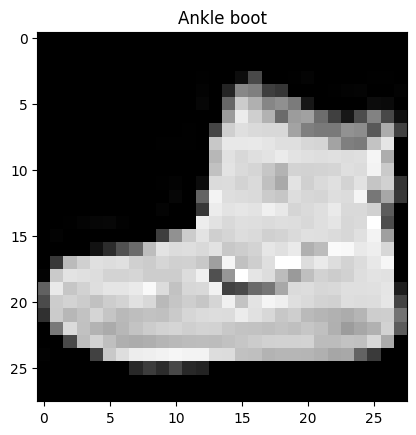

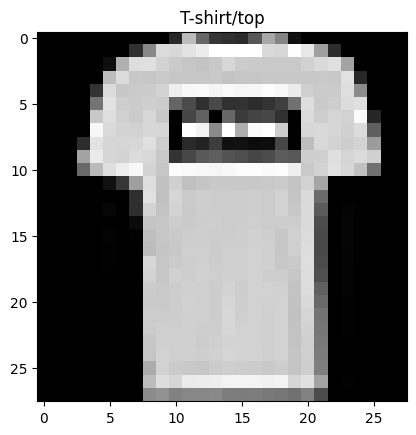

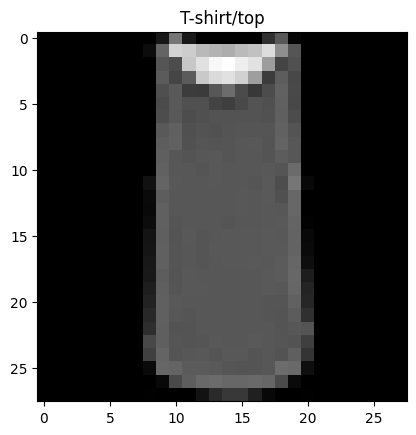

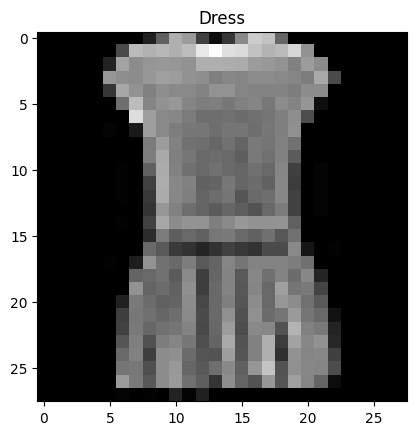

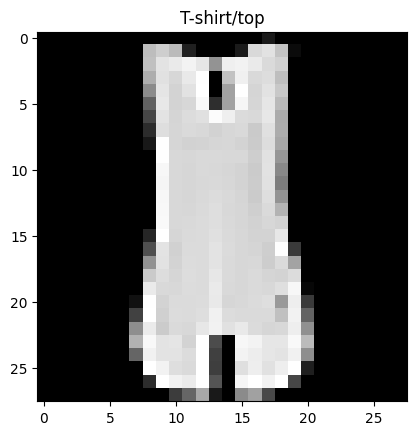

In [5]:
# write your code here

def plot_image(img, labels_map=None, y=None):
    plt.imshow(img, cmap="gray")
    if y is not None:
        if labels_map is not None:
            plt.title(labels_map[y])
        else:
            plt.title(y)
    plt.show()


for i in range(5):
    sample, label = train[i]
    #print(sample.squeeze().size())
    #print(train.classes)
    plot_image(sample.squeeze(), train.classes, label)


### Simulate limited access to labels

Let's simulate that we have labels for only a small portion of the data. We will use only this subset to train a Fashion-MNIST classifier. Note: we still keep *all* 60k images for the SSL pretext task in Section 3 - only the *labels* are restricted.

Use `torch.utils.data.DataLoader` to create data loaders for the training subset (use only **2%** of randomly sampled data) and the testing dataset. Batch size `64`, shuffling enabled for the training subset.

E.g.:

```python
n = len(train)
n_subset = int(0.02 * n)
train_subset, _ = torch.utils.data.random_split(
    train,
    [n_subset, n - n_subset],
    generator=torch.Generator().manual_seed(SEED),  # reproducible subset
)

train_subset_data_loader = torch.utils.data.DataLoader(
    train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2,
)

test_data_loader = torch.utils.data.DataLoader(
    test, batch_size=BATCH_SIZE, shuffle=False, num_workers=2,
)
```

> **Why 2%?** Real-world ML often has cheap *data* and expensive *labels* (medical, defect inspection, satellite). The whole point of SSL is the low-label regime.
>
> After building the subset, print a class histogram so you know what you actually got, and compare it with a class histogram for the whole dataset.
> **Stratification tip** A purely random 2% of 60k = 1200 samples can underrepresent some classes - exactly when you'd least want it. You can consider preparing a stratified version (120 per class).
> Optionally, an interesting thing to see is to check HOW the stratification or its absence actually impacts results of this lab. Once all your code is finished, run it again with stratification turned off.

In [6]:
# write your code here

n = len(train)
n_subset = int(0.02 * n)
train_subset, _ = torch.utils.data.random_split(
    train,
    [n_subset, n - n_subset],
    generator=torch.Generator().manual_seed(SEED),  # reproducible subset
)

train_subset_data_loader = torch.utils.data.DataLoader(
    train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
)

test_data_loader = torch.utils.data.DataLoader(
    test, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)



## 2. Define the model

Let's define a small CNN that will be our reference architecture for both the supervised baseline (here) and the RotNet (Section 3).

*You might want to reuse some of your code from the "Monte Carlo Dropout" lab.*

> **Architecture sanity check.** Trace the tensor shape through the network:
> `28 → conv → 26 → pool → 13 → conv → 11 → pool → 5 → conv → 3 → pool → 1`.
> After `Flatten` the feature vector is **32-dimensional** - small, but enough for this toy problem. If you want a stronger model, drop one `MaxPool2d` or widen the last conv (e.g. `Conv2d(64, 128, 3)`).
>
> **Note - dropout placement.** Earlier drafts of this lab had an extra `nn.Dropout()` between `Flatten()` and the final `Linear`. That dropout sits *on top of an already 1×1-spatial, 32-dim feature vector* - i.e., it zeroes out 50% of the features the classifier ever sees. It tends to make training noisy without helping generalization on this tiny model, so we leave it out. Keep the per-block dropouts after each pool; those are uncontroversial.
>
> **Note - `model.float()`** is essentially a no-op because PyTorch tensors default to float32. It only matters if you're explicitly converting from another dtype.

In [7]:
model = nn.Sequential(
    nn.Conv2d(1, 32, 3),        # B x 1 x 28 x 28
    nn.ReLU(),                  # B x 32 x 26 x 26
    nn.MaxPool2d(2),            # B x 32 x 13 x 13
    nn.Dropout(),               # B x 32 x 13 x 13
    nn.Conv2d(32, 64, 3),       # B x 64 x 11 x 11
    nn.ReLU(),                  # B x 64 x 11 x 11
    nn.MaxPool2d(2),            # B x 64 x 5 x 5
    nn.Dropout(),               # B x 64 x 5 x 5
    nn.Conv2d(64, 32, 3),       # B x 32 x 3 x 3
    #nn.Conv2d(64, 128, 3),       # B x 128 x 3 x 3
    nn.ReLU(),                  # B x 32 x 3 x 3 / # B x 128 x 3 x 3
    nn.MaxPool2d(2),            # B x 32 x 1 x 1 / # B x 128 x 1 x 1
    nn.Flatten(),               # B x 32 / # B x 128
    nn.Linear(32, 10),          # B x 10
    #nn.Linear(128, 10),          # B x 10
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss(reduction="sum")


### Training and evaluation functions


> **Note - `reduction="sum"`.** With sum-reduction, the per-epoch running total is divided by `len(dataloader.dataset)` to give an **average loss per sample**. This is comparable across runs with different batch sizes. Switching to `reduction="mean"` requires dividing by `len(dataloader)` (number of batches) instead.
>
> **Why BAC?** Balanced accuracy is the macro-average of per-class recall. With a small (possibly imbalanced) 2% subset, plain accuracy can be misleading: a model that always predicts the majority class can look "OK" on accuracy but is exposed by BAC.

In [8]:
from sklearn.metrics import balanced_accuracy_score

# modified version of: https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html#full-implementation
# license of this fragment: https://github.com/pytorch/pytorch/blob/master/LICENSE


def train_loop(dataloader, model, loss_fn, optimizer, num_epochs=1):
    result_loss = []
    size = len(dataloader.dataset)
    for _ in range(num_epochs):
        # Set the model to training mode - important for dropout / batch norm
        model.train()
        epoch_total_loss = 0
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss = loss_fn(pred, y)
            epoch_total_loss += loss.item()
            # Backpropagation
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        result_loss.append(epoch_total_loss / size)
    return result_loss


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode
    model.eval()
    size = len(dataloader.dataset)
    test_total_loss, labels_estimated, correct_labels = 0, [], []

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_total_loss += loss_fn(pred, y).item()
            correct_labels.extend(y.detach().cpu().numpy())
            labels_estimated.extend(pred.argmax(1).detach().cpu().numpy())

    bac = balanced_accuracy_score(correct_labels, labels_estimated)
    return test_total_loss / size, bac


### Utility - summarize a training run

Throughout this notebook you will produce four loss/BAC curves (baseline, RotNet pretext, linear probe, fine-tune). Rather than re-write `plt.subplot(...)` boilerplate four times, a good practice is to use a helper function like the one below - pass it the lists of per-epoch losses and BACs and it will draw the plot and append the final BAC to a results dictionary you can turn into a comparison table at the end.

In [9]:
results = {}   # name -> final test BAC; we will fill this in throughout the lab


def summarize_run(name, train_losses=None, test_losses=None, bacs=None, store=True):
    """Print a one-line summary, plot loss + BAC curves, optionally record final BAC.

    Parameters
    ----------
    name : str
        Identifier for this run (e.g. "baseline", "linear probe").
    train_losses, test_losses : list[float] | None
        Per-epoch losses to plot. If both are None, the loss panel is skipped.
    bacs : list[float] | None
        Per-epoch balanced accuracies to plot. Final value is recorded.
    store : bool
        If True and `bacs` is given, append `bacs[-1]` to the `results` dict.
    """
    has_loss = (train_losses is not None) or (test_losses is not None)
    has_bac  = bacs is not None
    n_panels = int(has_loss) + int(has_bac)

    if n_panels:
        fig, axes = plt.subplots(1, n_panels, figsize=(5.5 * n_panels, 4))
        if n_panels == 1:
            axes = [axes]
        i = 0
        if has_loss:
            if train_losses is not None:
                axes[i].plot(train_losses, label="train")
            if test_losses is not None:
                axes[i].plot(test_losses, label="test")
            axes[i].set_xlabel("epoch"); axes[i].set_ylabel("loss")
            axes[i].set_title(f"{name} — loss"); axes[i].legend()
            axes[i].grid(alpha=0.3)
            i += 1
        if has_bac:
            axes[i].plot(bacs)
            axes[i].set_xlabel("epoch"); axes[i].set_ylabel("BAC")
            axes[i].set_title(f"{name} — balanced accuracy")
            axes[i].grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    if has_bac and len(bacs) > 0:
        print(f"{name:<40s}  final BAC = {bacs[-1]:.4f}")
        if store:
            results[name] = bacs[-1]


def show_results_table():
    """Pretty-print the comparison table accumulated in `results`."""
    if not results:
        print("(no results recorded yet)")
        return
    width = max(len(k) for k in results) + 2
    print(f"{'Setup':<{width}}  {'Test BAC':>9}")
    print("-" * (width + 11))
    for k, v in results.items():
        print(f"{k:<{width}}  {v:>9.4f}")


### Experiment with the model

Train the model on `train_subset_data_loader` for several epochs (e.g., 15), evaluating on the test set every epoch. Collect per-epoch `train_losses`, `test_losses`, and `bacs`, then call:

```python
summarize_run("baseline (from scratch)", train_losses, test_losses, bacs)
```

This is your **baseline**. It will live in the `results` dict so you can compare it side-by-side with the SSL-pretrained variants in Section 4.

Epoch=0,	train loss=2.146,	test loss=1.952,	BAC=0.2882
Epoch=1,	train loss=1.687,	test loss=1.426,	BAC=0.5143
Epoch=2,	train loss=1.353,	test loss=1.174,	BAC=0.5757
Epoch=3,	train loss=1.159,	test loss=1.013,	BAC=0.6532
Epoch=4,	train loss=1.035,	test loss=0.9673,	BAC=0.6531
Epoch=5,	train loss=0.9819,	test loss=0.9022,	BAC=0.6637
Epoch=6,	train loss=0.8976,	test loss=0.8458,	BAC=0.6906
Epoch=7,	train loss=0.8866,	test loss=0.8294,	BAC=0.6881
Epoch=8,	train loss=0.8645,	test loss=0.8043,	BAC=0.701
Epoch=9,	train loss=0.8388,	test loss=0.7955,	BAC=0.6948
Epoch=10,	train loss=0.7992,	test loss=0.7706,	BAC=0.7101
Epoch=11,	train loss=0.7672,	test loss=0.7739,	BAC=0.7106
Epoch=12,	train loss=0.7756,	test loss=0.766,	BAC=0.7094
Epoch=13,	train loss=0.7568,	test loss=0.7841,	BAC=0.7064
Epoch=14,	train loss=0.7711,	test loss=0.7756,	BAC=0.7195


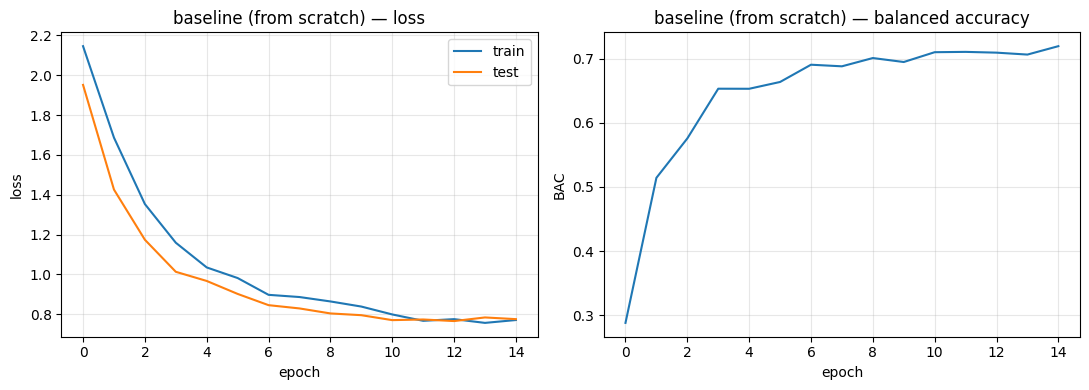

baseline (from scratch)                   final BAC = 0.7195


In [10]:
# write your code here
n_epochs = 15
train_losses = np.zeros(n_epochs)
test_losses = np.zeros(n_epochs)
bacs = np.zeros(n_epochs)

for epoch in range(n_epochs):
    train_losses[epoch] = train_loop(train_subset_data_loader, model, loss_fn, optimizer)[0]
    test_losses[epoch], bacs[epoch] = test_loop(test_data_loader, model, loss_fn)
    print(f"Epoch={epoch},\ttrain loss={train_losses[epoch]:.4},\ttest loss={test_losses[epoch]:.4},\tBAC={bacs[epoch]:.4}")

summarize_run("baseline (from scratch)", train_losses, test_losses, bacs)

## 3. Learning representation with RotNet

Train a RotNet on the **entire** training set using a "pretext" task with a categorical output predicting the rotation applied to the image:

1. image not rotated (`k=0`)
2. image rotated by 90°  (`k=1`)
3. image rotated by 180° (`k=2`)
4. image rotated by 270° (`k=3`)

Important: we use *every* image in the training set, but **we do not use the true Fashion-MNIST labels here** — only the synthetic rotation labels that we generate ourselves. This is what makes the task "self-supervised".

We split the network explicitly into a **backbone** (the feature extractor we will reuse) and a **head** (the rotation classifier we will throw away).

> **State-management trap.** This cell **rebinds** the globals `optimizer` and `loss_fn`. If you later re-run the supervised baseline cell for comparison, **redefine its optimizer explicitly first** - otherwise you'll be optimizing `model_rotnet.parameters()` instead of `model.parameters()`. Always create a fresh optimizer right before training the model you actually want to train.

In [11]:
model_rotnet_backbone = nn.Sequential(  #B x 1 x 28 x 28
    nn.Conv2d(1, 32, 3),                #B x 32 x 26 x 26
    nn.ReLU(),                          #B x 32 x 26 x 26
    nn.MaxPool2d(2),                    #B x 32 x 13 x 13
    nn.Dropout(),                       #B x 32 x 13 x 13
    nn.Conv2d(32, 64, 3),               #B x 64 x 11 x 11
    nn.ReLU(),                          #B x 64 x 11 x 11
    nn.MaxPool2d(2),                    #B x 64 x 5 x 5
    nn.Dropout(),                       #B x 64 x 5 x 5
    nn.Conv2d(64, 32, 3),               #B x 32 x 3 x 3
    #nn.Conv2d(64, 128, 3),               #B x 128 x 3 x 3
    nn.ReLU(),                          #B x 32 x 3 x 3 / #B x 128 x 3 x 3
    nn.MaxPool2d(2),                    #B x 32 x 1 x 1 / #B x 128 x 1 x 1
    nn.Flatten(),                       #B x 32 / #B x 128
)

model_rotnet = nn.Sequential(   #B x 1 x 28 x 28
    model_rotnet_backbone,  #B x 32
    nn.Linear(32, 4),       # 4 rotation classes
    #nn.Linear(128, 4),       # 4 rotation classes
).to(device)

optimizer = torch.optim.Adam(model_rotnet.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss(reduction="sum")


### Prepare the "pretext" dataset

Build a `Dataset` that, for each item in the underlying Fashion-MNIST training set, returns a **rotated image and its rotation index** (instead of the original class label).

E.g.:

```python
from torch.utils.data.dataset import Dataset

class RotNetDataset(Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __getitem__(self, index):
        # TODO: implement
        ...

    def __len__(self):
        return len(self.base)

rotnet_dataset = RotNetDataset(train)

rotnet_data_loader = torch.utils.data.DataLoader(
    rotnet_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2,
)
```

> **Hint — `torch.rot90` is your friend.** For an image tensor of shape `(C, H, W)`:
>
> ```python
> rotated = torch.rot90(img, k, dims=[1, 2])   # k in {0, 1, 2, 3}
> ```
>
> Two sensible strategies inside `__getitem__`:
>
> - **Random `k`** (simpler, slightly noisier):
>   ```python
>   img, _ = self.base[index]
>   k = random.randint(0, 3)
>   return torch.rot90(img, k, dims=[1, 2]), k
>   ```
> - **Deterministic `k = index % 4`** - every epoch covers all 4 rotations of every image, giving a less noisy signal.
>
> **Caveat.** Some classes (bags, simple shirts) are nearly horizontally symmetric - the pretext task cannot perfectly resolve their orientation. That's fine; the network learns plenty from the rest.
>
> **Not the same as augmentation.** In data augmentation you rotate the input and **keep** the original class label. Here, the rotation **is** the label and the original class is discarded.

In [12]:
# write your code here
from torch.utils.data.dataset import Dataset

class RotNetDataset(Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __getitem__(self, index):
        img, _ = self.base[index]
        k = index % 4
        return torch.rot90(img, k, dims=[1, 2]), k

    def __len__(self):
        return len(self.base)

rotnet_dataset = RotNetDataset(train)
rotnet_testset = RotNetDataset(test)

rotnet_data_loader = torch.utils.data.DataLoader(
    rotnet_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
)

rotnet_test_data_loader = torch.utils.data.DataLoader(
    rotnet_testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
)


In [13]:
for i in range(5):
    img, label = rotnet_dataset[i]
    #plot_image(img.squeeze(), y=label)

### Train the RotNet network

Train `model_rotnet` on `rotnet_data_loader` for a few epochs (the full 60k-image training set is large - even 3–5 epochs is plenty). Also evaluate it: build a held-out rotnet validation loader by wrapping `test` in another `RotNetDataset`, and run `test_loop` on it each epoch. Then:

```python
summarize_run("RotNet pretext", train_losses, test_losses, bacs, store=False)
```

`store=False` because pretext-task BAC is not comparable to downstream BAC - it lives on a different label space (4 rotation classes vs. 10 clothing classes).

**What to look for:**
- Pretext BAC should rise well above chance (chance is 0.25 for 4 classes). If it hovers near 0.25 your pretext dataset isn't rotating the images, or your labels aren't matching.
- It should *not* hit 1.00 in epoch 1 - that would mean a trivial cue (e.g., padding artifact) gives the answer away.
- High rotation BAC is **necessary but not sufficient** for good downstream features. A network can solve rotation prediction using low-level cues (border artifacts, padding asymmetries) without learning anything semantically useful. The real test is Section 4.

Epoch=0,	train loss=0.6898,	test loss=0.3835,	BAC=0.8738
Epoch=1,	train loss=0.4034,	test loss=0.2691,	BAC=0.9128
Epoch=2,	train loss=0.3276,	test loss=0.2114,	BAC=0.9297
Epoch=3,	train loss=0.2886,	test loss=0.1975,	BAC=0.9383
Epoch=4,	train loss=0.2637,	test loss=0.1816,	BAC=0.9448


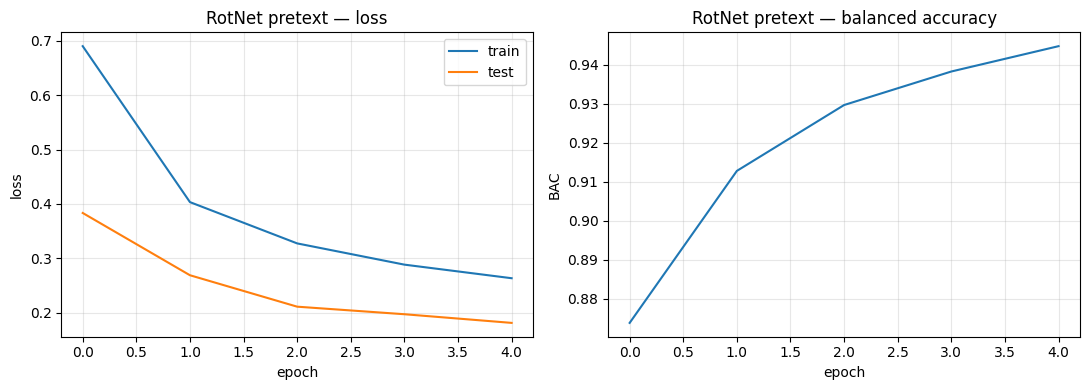

RotNet pretext                            final BAC = 0.9448


In [14]:
# write your code here
n_epochs = 5
train_losses = np.zeros(n_epochs)
test_losses = np.zeros(n_epochs)
bacs = np.zeros(n_epochs)

for epoch in range(n_epochs):
    train_losses[epoch] = train_loop(rotnet_data_loader, model_rotnet, loss_fn, optimizer)[0]
    test_losses[epoch], bacs[epoch] = test_loop(rotnet_test_data_loader, model_rotnet, loss_fn)
    print(f"Epoch={epoch},\ttrain loss={train_losses[epoch]:.4f},\ttest loss={test_losses[epoch]:.4f},\tBAC={bacs[epoch]:.4f}")

summarize_run("RotNet pretext", train_losses, test_losses, bacs, store=False)




## 4. Use the trained representation for the downstream task

Use the RotNet's **backbone** to address the actual Fashion-MNIST classification task. Build a new model = (backbone) + (fresh 10-class linear head). Train it on the same `train_subset_data_loader` (2% labels) and compare against your Section-2 baseline.

> **Backbone reuse - pick one mode.** Three valid choices, each answers a different question:
>
> **A. Share by reference** - gradients flow back into the original `model_rotnet_backbone`. The downstream model and the pretrained backbone are *the same object*. Simple, but you destroy the pretrained weights as a side effect and can't compare modes A/B/C from the same starting point afterwards.
> ```python
> model_fine_tuned = nn.Sequential(model_rotnet_backbone, nn.Linear(32, 10)).to(device)
> optimizer = torch.optim.Adam(model_fine_tuned.parameters(), lr=1e-3)
> ```
>
> **B. Deep copy, fully trainable** - independent backbone for this experiment, all parameters update. Use this if you want to keep `model_rotnet_backbone` pristine for further experiments.
> ```python
> backbone = copy.deepcopy(model_rotnet_backbone)
> model_fine_tuned = nn.Sequential(backbone, nn.Linear(32, 10)).to(device)
> optimizer = torch.optim.Adam(model_fine_tuned.parameters(), lr=1e-3)
> ```
>
> **C. Freeze the backbone** - "linear probing". Only the linear head trains. Measures how good the *frozen* representation is on its own.
> ```python
> backbone = copy.deepcopy(model_rotnet_backbone)
> for p in backbone.parameters():
>     p.requires_grad = False
> model_fine_tuned = nn.Sequential(backbone, nn.Linear(32, 10)).to(device)
> optimizer = torch.optim.Adam(
>     filter(lambda p: p.requires_grad, model_fine_tuned.parameters()), lr=1e-3
> )
> ```
>
> Run **both B (fine-tune)** and **C (linear probe)** and compare to your Section-2 from-scratch baseline. These three results answer different questions:
>
> - **Linear probe (C)** measures how much *useful structure* the pretrained backbone learned - can a single linear layer separate the 10 classes on top of those frozen features?
> - **Fine-tune (B) vs. from-scratch baseline** measures how much SSL pretraining is worth as a *starting point* for the downstream task, holding everything else equal.
> - **Fine-tune (B) vs. linear probe (C)** measures how much extra performance you get from adapting the backbone to the downstream task, vs. keeping it frozen.
>
> Whether C beats the baseline, ties it, or falls short depends on how strong the pretrained representation is and how much capacity the linear head has - with only 32 frozen features and 10 classes, a slightly smaller C is realistic. B is the comparison that more cleanly says "pretraining helped".

### First perform C

Epoch=0,	train loss=2.993,	test loss=2.581,	BAC=0.0935
Epoch=1,	train loss=2.466,	test loss=2.243,	BAC=0.1573
Epoch=2,	train loss=2.174,	test loss=2.01,	BAC=0.2404
Epoch=3,	train loss=1.946,	test loss=1.834,	BAC=0.3026
Epoch=4,	train loss=1.781,	test loss=1.692,	BAC=0.3735
Epoch=5,	train loss=1.631,	test loss=1.579,	BAC=0.4586
Epoch=6,	train loss=1.531,	test loss=1.489,	BAC=0.5206
Epoch=7,	train loss=1.439,	test loss=1.414,	BAC=0.5588
Epoch=8,	train loss=1.375,	test loss=1.356,	BAC=0.5842
Epoch=9,	train loss=1.307,	test loss=1.301,	BAC=0.6098
Epoch=10,	train loss=1.263,	test loss=1.256,	BAC=0.627
Epoch=11,	train loss=1.215,	test loss=1.218,	BAC=0.6374
Epoch=12,	train loss=1.184,	test loss=1.184,	BAC=0.6445
Epoch=13,	train loss=1.162,	test loss=1.153,	BAC=0.6572
Epoch=14,	train loss=1.116,	test loss=1.129,	BAC=0.6564


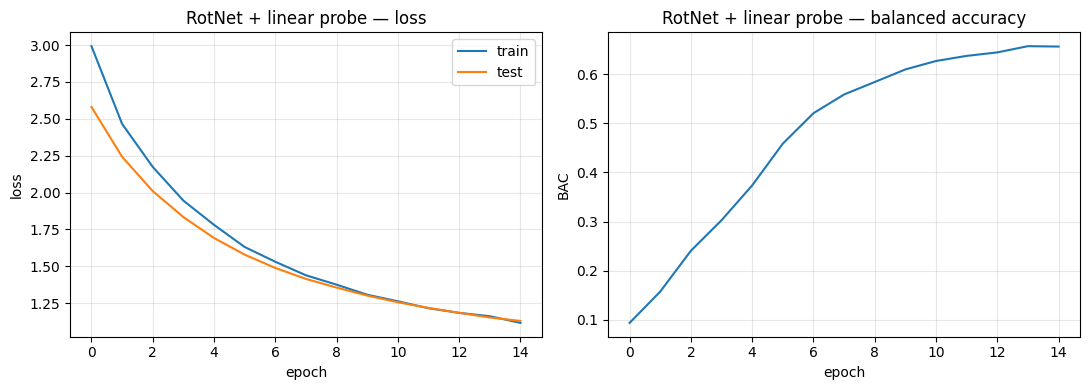

RotNet + linear probe                     final BAC = 0.6564


In [15]:
# write your code here
backbone = copy.deepcopy(model_rotnet_backbone)
for p in backbone.parameters():
    p.requires_grad = False
model_fine_tuned_C = nn.Sequential(backbone, nn.Linear(32, 10)).to(device)
optimizer = torch.optim.Adam( filter(lambda p: p.requires_grad, model_fine_tuned_C.parameters()), lr=1e-3)
loss_fn = nn.CrossEntropyLoss(reduction="sum")

n_epochs = 15
train_losses = np.zeros(n_epochs)
test_losses = np.zeros(n_epochs)
bacs = np.zeros(n_epochs)

for epoch in range(n_epochs):
    train_losses[epoch] = train_loop(train_subset_data_loader, model_fine_tuned_C, loss_fn, optimizer)[0]
    test_losses[epoch], bacs[epoch] = test_loop(test_data_loader, model_fine_tuned_C, loss_fn)
    print(f"Epoch={epoch},\ttrain loss={train_losses[epoch]:.4},\ttest loss={test_losses[epoch]:.4},\tBAC={bacs[epoch]:.4}")

summarize_run("RotNet + linear probe", train_losses, test_losses, bacs)


### And now B

Epoch=0,	train loss=2.273,	test loss=1.856,	BAC=0.4043
Epoch=1,	train loss=1.534,	test loss=1.263,	BAC=0.6102
Epoch=2,	train loss=1.098,	test loss=0.9284,	BAC=0.6895
Epoch=3,	train loss=0.9295,	test loss=0.8251,	BAC=0.7154
Epoch=4,	train loss=0.8487,	test loss=0.7731,	BAC=0.7312
Epoch=5,	train loss=0.8091,	test loss=0.7322,	BAC=0.7466
Epoch=6,	train loss=0.7676,	test loss=0.718,	BAC=0.748
Epoch=7,	train loss=0.738,	test loss=0.7014,	BAC=0.7525
Epoch=8,	train loss=0.7153,	test loss=0.6734,	BAC=0.7615
Epoch=9,	train loss=0.6999,	test loss=0.6833,	BAC=0.7614
Epoch=10,	train loss=0.64,	test loss=0.6581,	BAC=0.7644
Epoch=11,	train loss=0.6433,	test loss=0.6524,	BAC=0.7682
Epoch=12,	train loss=0.6143,	test loss=0.6224,	BAC=0.7789
Epoch=13,	train loss=0.6044,	test loss=0.6285,	BAC=0.7771
Epoch=14,	train loss=0.5798,	test loss=0.6051,	BAC=0.7875


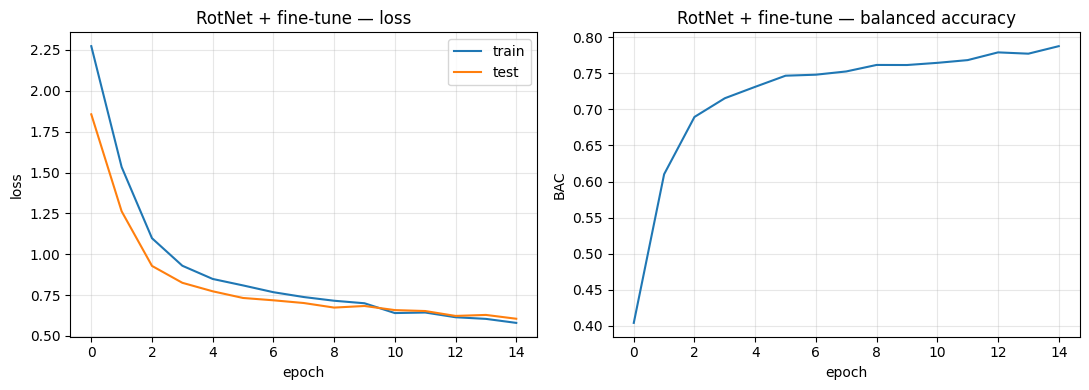

RotNet + fine-tune                        final BAC = 0.7875


In [16]:
backbone = copy.deepcopy(model_rotnet_backbone)
model_fine_tuned_B = nn.Sequential(backbone, nn.Linear(32, 10)).to(device)
optimizer = torch.optim.Adam(model_fine_tuned_B.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss(reduction="sum")

n_epochs = 15
train_losses = np.zeros(n_epochs)
test_losses = np.zeros(n_epochs)
bacs = np.zeros(n_epochs)

for epoch in range(n_epochs):
    train_losses[epoch] = train_loop(train_subset_data_loader, model_fine_tuned_B, loss_fn, optimizer)[0]
    test_losses[epoch], bacs[epoch] = test_loop(test_data_loader, model_fine_tuned_B, loss_fn)
    print(f"Epoch={epoch},\ttrain loss={train_losses[epoch]:.4},\ttest loss={test_losses[epoch]:.4},\tBAC={bacs[epoch]:.4}")

summarize_run("RotNet + fine-tune", train_losses, test_losses, bacs)

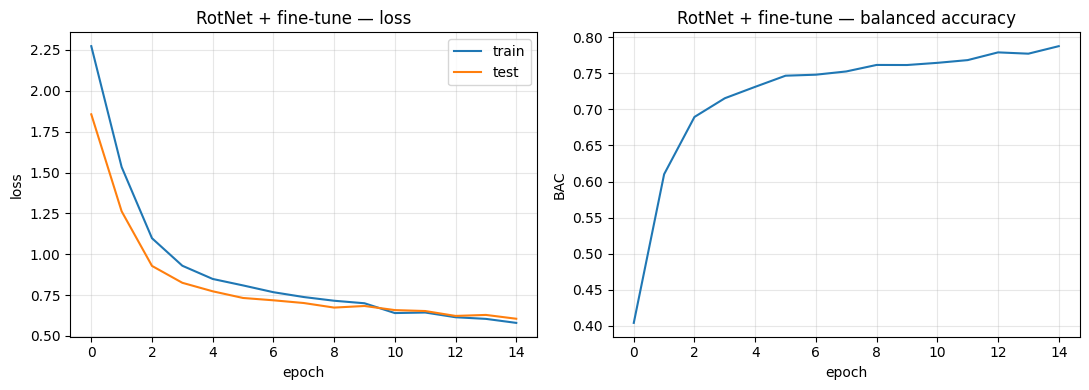

RotNet + fine-tune                        final BAC = 0.7875


In [17]:
summarize_run("RotNet + fine-tune", train_losses, test_losses, bacs)

In [18]:
show_results_table()

Setup                       Test BAC
------------------------------------
baseline (from scratch)       0.7195
RotNet + linear probe         0.6564
RotNet + fine-tune            0.7875


### Fine-tune the models and compare

Train your linear-probe (C) and fine-tune (B) variants on `train_subset_data_loader` for the **same number of epochs** as your Section-2 baseline, using the **same loss function**. Wrap each run in:

```python
summarize_run("RotNet + linear probe", train_losses, test_losses, bacs)
summarize_run("RotNet + fine-tune",    train_losses, test_losses, bacs)
```

Then call `show_results_table()` to print the comparison.

#### What to look for (not exact numbers - signals)

SSL on small models with small subsets is noisy; specific BACs fluctuate several percentage points across seeds. What should be qualitatively robust:

| Signal | Expected outcome | If you don't see it, plausible causes |
|---|---|---|
| **Fine-tune typically ≥ from-scratch baseline**, often by several pp | Pretrained features give a head start when fine-tuning. | (a) pretext task didn't learn enough - check that pretext BAC was well above 0.25; (b) you re-used a fresh backbone instead of the trained one - print a parameter sample before/after to verify; (c) the gap is real but smaller than single-seed noise - run a second or third seed; (d) fine-tuning learning rate too high, destroying the pretrained features in the first few epochs - try `1e-4`. |
| **Linear probe BAC is well above 10% chance** | Even with a frozen backbone, the RotNet representation supports linear separability of the 10 classes far better than chance. | Backbone wasn't actually frozen (check `requires_grad`), or the pretext task didn't learn useful features. |
| **Run-to-run variance across seeds is a few pp** | 1200 labels is small; this is normal. | If runs are identical across seeds, you aren't re-seeding (or re-initializing the model) between runs. |

**Linear probe vs. fine-tune - which should be higher?** Depends on model size and task difficulty. With this small backbone, fine-tuning usually wins because 32 frozen features may not be linearly separable enough for 10 classes. With larger pretrained models on harder tasks (the regime modern SSL papers report on), linear probing can match or even beat fine-tuning. Reporting both is the point - the *gap* between them is the value of task-adaptive fine-tuning.

#### Make it (somewhat) reproducible

Repeat the comparison with at least 2-3 different seeds and report mean ± std. A single-seed comparison on 1200 samples is not enough to distinguish a real effect from noise. Same epoch count, same loss function, same loader settings - only the SSL pretraining should differ.

#### Optional - a cleaner measure of representation quality

If you want to be quantitative about *what the pretext task actually learned* (rather than how it transfers), run one extra control: take a **freshly initialized, untrained** backbone (same architecture), freeze it, and train only a linear head on the 2% subset. Call this the **random-init linear probe**. Compare it to your **RotNet linear probe**. The gap between these two isolates "the backbone learned something useful from rotation prediction" from "training a linear classifier on 1200 examples gets you somewhere regardless of features". Random conv features are surprisingly informative (see Saxe et al. 2011, *On Random Weights and Unsupervised Feature Learning*) - don't be surprised if the random-init probe is already well above chance. The interesting quantity is the difference.

In [19]:
def reset_weights(m):
    """
    Funkcja przechodzi przez moduły sieci i wywołuje reset ich parametrów,
    jeśli posiadają taką metodę (np. warstwy Conv2d).
    """
    if hasattr(m, 'reset_parameters'):
        m.reset_parameters()

In [20]:
# write your code here

seeds = [21, 123, 999]

# Dicts for final BAC values
results = {
    "baseline": [],
    "linear_probe": [],
    "fine_tune": []
}

for SEED in seeds:
    print(f"\n=== RUN WITH SEED = {SEED} ===")
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    #torch.cuda.manual_seed_all(SEED)
    model_rotnet_backbone.apply(reset_weights)

    # 1. dataloaders (they use SEED)

    n = len(train)
    n_subset = int(0.02 * n)
    train_subset, _ = torch.utils.data.random_split(
        train,
        [n_subset, n - n_subset],
        generator=torch.Generator().manual_seed(SEED),  # reproducible subset
    )

    train_subset_data_loader = torch.utils.data.DataLoader(
        train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
    )

    test_data_loader = torch.utils.data.DataLoader(
        test, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
    )


    # 2. Trenujesz model od zera (baseline) -> zapisujesz końcowy BAC do results["baseline"]

    model = nn.Sequential(
        nn.Conv2d(1, 32, 3),        # B x 1 x 28 x 28
        nn.ReLU(),                  # B x 32 x 26 x 26
        nn.MaxPool2d(2),            # B x 32 x 13 x 13
        nn.Dropout(),               # B x 32 x 13 x 13
        nn.Conv2d(32, 64, 3),       # B x 64 x 11 x 11
        nn.ReLU(),                  # B x 64 x 11 x 11
        nn.MaxPool2d(2),            # B x 64 x 5 x 5
        nn.Dropout(),               # B x 64 x 5 x 5
        nn.Conv2d(64, 32, 3),       # B x 32 x 3 x 3
        #nn.Conv2d(64, 128, 3),     # B x 128 x 3 x 3
        nn.ReLU(),                  # B x 32 x 3 x 3 / # B x 128 x 3 x 3
        nn.MaxPool2d(2),            # B x 32 x 1 x 1 / # B x 128 x 1 x 1
        nn.Flatten(),               # B x 32 / # B x 128
        nn.Linear(32, 10),          # B x 10
        #nn.Linear(128, 10),          # B x 10
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss(reduction="sum")

    # training baseline
    n_epochs = 15
    train_losses = np.zeros(n_epochs)
    test_losses = np.zeros(n_epochs)
    bacs = np.zeros(n_epochs)

    print("\n\nTraining the baseline model:")
    for epoch in range(n_epochs):
        train_losses[epoch] = train_loop(train_subset_data_loader, model, loss_fn, optimizer)[0]
        test_losses[epoch], bacs[epoch] = test_loop(test_data_loader, model, loss_fn)
        print(f"Epoch={epoch},\ttrain loss={train_losses[epoch]:.4},\ttest loss={test_losses[epoch]:.4},\tBAC={bacs[epoch]:.4}")

    results["baseline"].append(bacs[-1])

    # 3. Train model RotNet (pretext task)
    model_rotnet_backbone = nn.Sequential(  #B x 1 x 28 x 28
        nn.Conv2d(1, 32, 3),                #B x 32 x 26 x 26
        nn.ReLU(),                          #B x 32 x 26 x 26
        nn.MaxPool2d(2),                    #B x 32 x 13 x 13
        nn.Dropout(),                       #B x 32 x 13 x 13
        nn.Conv2d(32, 64, 3),               #B x 64 x 11 x 11
        nn.ReLU(),                          #B x 64 x 11 x 11
        nn.MaxPool2d(2),                    #B x 64 x 5 x 5
        nn.Dropout(),                       #B x 64 x 5 x 5
        nn.Conv2d(64, 32, 3),               #B x 32 x 3 x 3
        #nn.Conv2d(64, 128, 3),               #B x 128 x 3 x 3
        nn.ReLU(),                          #B x 32 x 3 x 3 / #B x 128 x 3 x 3
        nn.MaxPool2d(2),                    #B x 32 x 1 x 1 / #B x 128 x 1 x 1
        nn.Flatten(),                       #B x 32 / #B x 128
    )

    model_rotnet = nn.Sequential(   #B x 1 x 28 x 28
        model_rotnet_backbone,  #B x 32
        nn.Linear(32, 4),       # 4 rotation classes
        #nn.Linear(128, 4),       # 4 rotation classes
    ).to(device)

    optimizer = torch.optim.Adam(model_rotnet.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss(reduction="sum")

    rotnet_dataset = RotNetDataset(train)
    rotnet_testset = RotNetDataset(test)

    rotnet_data_loader = torch.utils.data.DataLoader(
        rotnet_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
    )

    rotnet_test_data_loader = torch.utils.data.DataLoader(
        rotnet_testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
    )

    #training

    n_epochs = 5
    train_losses = np.zeros(n_epochs)
    test_losses = np.zeros(n_epochs)
    bacs = np.zeros(n_epochs)

    print("\n\nTraining for the pretext task:")
    for epoch in range(n_epochs):
        train_losses[epoch] = train_loop(rotnet_data_loader, model_rotnet, loss_fn, optimizer)[0]
        test_losses[epoch], bacs[epoch] = test_loop(rotnet_test_data_loader, model_rotnet, loss_fn)
        print(f"Epoch={epoch},\ttrain loss={train_losses[epoch]:.4f},\ttest loss={test_losses[epoch]:.4f},\tBAC={bacs[epoch]:.4f}")

    # 4. Version C (linear probe) -> final BAC to results["linear_probe"]

    backbone = copy.deepcopy(model_rotnet_backbone)
    for p in backbone.parameters():
        p.requires_grad = False
    model_fine_tuned_C = nn.Sequential(backbone, nn.Linear(32, 10)).to(device)
    optimizer = torch.optim.Adam( filter(lambda p: p.requires_grad, model_fine_tuned_C.parameters()), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss(reduction="sum")

    n_epochs = 15
    train_losses = np.zeros(n_epochs)
    test_losses = np.zeros(n_epochs)
    bacs = np.zeros(n_epochs)

    print("\n\nTraining the linear probe model:")
    for epoch in range(n_epochs):
        train_losses[epoch] = train_loop(train_subset_data_loader, model_fine_tuned_C, loss_fn, optimizer)[0]
        test_losses[epoch], bacs[epoch] = test_loop(test_data_loader, model_fine_tuned_C, loss_fn)
        print(f"Epoch={epoch},\ttrain loss={train_losses[epoch]:.4},\ttest loss={test_losses[epoch]:.4},\tBAC={bacs[epoch]:.4}")

    results["linear_probe"].append(bacs[-1])

    # 5. Version B (fine-tune) -> final BAC to results["fine_tune"]

    backbone = copy.deepcopy(model_rotnet_backbone)
    model_fine_tuned_B = nn.Sequential(backbone, nn.Linear(32, 10)).to(device)
    optimizer = torch.optim.Adam(model_fine_tuned_B.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss(reduction="sum")

    n_epochs = 15
    train_losses = np.zeros(n_epochs)
    test_losses = np.zeros(n_epochs)
    bacs = np.zeros(n_epochs)

    print("\n\nTraining the fine-tuned model:")
    for epoch in range(n_epochs):
        train_losses[epoch] = train_loop(train_subset_data_loader, model_fine_tuned_B, loss_fn, optimizer)[0]
        test_losses[epoch], bacs[epoch] = test_loop(test_data_loader, model_fine_tuned_B, loss_fn)
        print(f"Epoch={epoch},\ttrain loss={train_losses[epoch]:.4},\ttest loss={test_losses[epoch]:.4},\tBAC={bacs[epoch]:.4}")

    results["fine_tune"].append(bacs[-1])





=== RUN WITH SEED = 21 ===


Training the baseline model:
Epoch=0,	train loss=2.23,	test loss=2.112,	BAC=0.3396
Epoch=1,	train loss=1.804,	test loss=1.562,	BAC=0.4401
Epoch=2,	train loss=1.366,	test loss=1.192,	BAC=0.5737
Epoch=3,	train loss=1.143,	test loss=1.057,	BAC=0.633
Epoch=4,	train loss=1.018,	test loss=0.9437,	BAC=0.6785
Epoch=5,	train loss=0.955,	test loss=0.881,	BAC=0.6715
Epoch=6,	train loss=0.8869,	test loss=0.8421,	BAC=0.694
Epoch=7,	train loss=0.8399,	test loss=0.8176,	BAC=0.6922
Epoch=8,	train loss=0.8063,	test loss=0.8346,	BAC=0.7084
Epoch=9,	train loss=0.7953,	test loss=0.7869,	BAC=0.7163
Epoch=10,	train loss=0.7632,	test loss=0.7444,	BAC=0.7273
Epoch=11,	train loss=0.7282,	test loss=0.7464,	BAC=0.7268
Epoch=12,	train loss=0.7121,	test loss=0.7402,	BAC=0.7292
Epoch=13,	train loss=0.6801,	test loss=0.7169,	BAC=0.7367
Epoch=14,	train loss=0.654,	test loss=0.7018,	BAC=0.7389


Training for the pretext task:
Epoch=0,	train loss=0.6506,	test loss=0.3358,	BAC=0.8933
Epoch=

In [21]:
print("=== OSTATECZNE WYNIKI MODELI (Mean ± Std) ===")
print("-" * 45)

# Automatyczna pętla wyciągająca klucz (nazwę) i listę wyników BAC
for model_name, bac_values in results.items():
    # Liczymy średnią i odchylenie standardowe za pomocą NumPy
    mean_val = np.mean(bac_values)
    std_val = np.std(bac_values)

    # Wypisujemy wynik sformatowany do 4 miejsc po przecinku (: .4f)
    print(f"{model_name:<25} :  {mean_val:.4f} ± {std_val:.4f}")

print("-" * 45)

=== OSTATECZNE WYNIKI MODELI (Mean ± Std) ===
---------------------------------------------
baseline                  :  0.7404 ± 0.0030
linear_probe              :  0.6462 ± 0.0114
fine_tune                 :  0.7726 ± 0.0068
---------------------------------------------


## 5\*. Extension - does a flip-prediction head help?

**Concrete task:** add a second self-supervised pretext task - predicting whether the image has been horizontally flipped - and check whether multi-task pretraining produces a better backbone than rotation alone.

**Steps:**

1. Build a `MultiPretextDataset` whose `__getitem__` returns `(image, k_rot, k_flip)` where `k_rot ∈ {0,1,2,3}` is the rotation and `k_flip ∈ {0,1}` is whether the image was horizontally flipped (you choose both at random per item, then apply them in order).
2. Build a multi-head model around your existing backbone:

   ```python
   class MultiHead(nn.Module):
       def __init__(self, backbone):
           super().__init__()
           self.backbone = backbone
           self.head_rot  = nn.Linear(32, 4)
           self.head_flip = nn.Linear(32, 2)
       def forward(self, x):
           z = self.backbone(x)
           return self.head_rot(z), self.head_flip(z)
   ```

3. Train with `loss = ce(rot_logits, k_rot) + ce(flip_logits, k_flip)`. (You can also try weighting them; start with equal weight.)
4. Run the same downstream comparison as in Section 4 (linear probe + fine-tune on the 2% subset). Record results with `summarize_run`, e.g. `"multi-pretext + linear probe"` and `"multi-pretext + fine-tune"`.
5. Call `show_results_table()` to compare all four downstream variants side-by-side.

**The actual question to answer in your write-up:** does the multi-task pretrained backbone outperform the rotation-only one on the downstream task? Is the gap large enough to be confident it's real given run-to-run variance? Why or why not?

> **Heads up - flip + rotation interaction.** A horizontal flip followed by a 180° rotation equals a vertical flip; this means the two pretext tasks aren't fully independent. That's fine - it's part of what makes this experiment interesting.

### Optional follow-ups (if you still have time)

- **Lower the fine-tuning learning rate** (try `1e-4`) - does it close the gap between linear probe and fine-tune?
- **Replace the rotation head with an autoencoder head.** Decoder = small stack of `ConvTranspose2d` layers, loss = MSE between input and reconstruction. Does the resulting backbone transfer as well as RotNet?
- **Run all comparisons across 3 seeds and report mean ± std.** Often the more revealing experiment than trying new variants.

### New training loop function

In [22]:
def train_loop_multi(dataloader, model, loss_fn, optimizer):
    model.train()
    size = len(dataloader.dataset)
    epoch_total_loss = 0

    for X, y_rot, y_flip in dataloader:
        X, y_rot, y_flip = X.to(device), y_rot.to(device), y_flip.to(device)

        # Forward pass (model zwraca krotkę dwóch tensorów)
        pred_rot, pred_flip = model(X)

        # Liczymy obie straty i sumujemy je
        loss_rot = loss_fn(pred_rot, y_rot)
        loss_flip = loss_fn(pred_flip, y_flip)
        loss = loss_rot + loss_flip

        epoch_total_loss += loss.item()

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return [epoch_total_loss / size]



def test_loop_multi(dataloader, model, loss_fn):
    # Set the model to evaluation mode
    model.eval()
    size = len(dataloader.dataset)
    test_total_loss = 0

    # lists for true labels and predictions
    correct_rot, estimated_rot = [], []
    correct_flip, estimated_flip = [], []

    # turn off gradients
    with torch.no_grad():
        for X, y_rot, y_flip in dataloader:
            X, y_rot, y_flip = X.to(device), y_rot.to(device), y_flip.to(device)

            # Forward pass (both heads)
            pred_rot, pred_flip = model(X)

            # summing test errors
            loss_rot = loss_fn(pred_rot, y_rot)
            loss_flip = loss_fn(pred_flip, y_flip)
            test_total_loss += (loss_rot + loss_flip).item()

            # results for rotation
            correct_rot.extend(y_rot.detach().cpu().numpy())
            estimated_rot.extend(pred_rot.argmax(1).detach().cpu().numpy())

            # results for flipping
            correct_flip.extend(y_flip.detach().cpu().numpy())
            estimated_flip.extend(pred_flip.argmax(1).detach().cpu().numpy())

    # BACs for both classification tasks
    bac_rot = balanced_accuracy_score(correct_rot, estimated_rot)
    bac_flip = balanced_accuracy_score(correct_flip, estimated_flip)

    # return avg loss and two BACs values
    return test_total_loss / size, bac_rot, bac_flip

### New dataset

In [23]:
class MultiPretextDataset(Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __getitem__(self, index):
        img, _ = self.base[index]

        # 1. transformation parameters
        k_rot = random.randint(0, 3)
        k_flip = random.randint(0, 1)  # 0 = no flip, 1 = flip

        # 2. rotation
        img = torch.rot90(img, k_rot, dims=[1, 2])

        # 3. horizontal flip
        if k_flip == 1:
            img = torch.flip(img, dims=[2])  # dims=[2] is an X axis (width)

        return img, k_rot, k_flip

    def __len__(self):
        return len(self.base)

#####   Dataloaders and neural network

class MultiHead(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.head_rot  = nn.Linear(32, 4)
        self.head_flip = nn.Linear(32, 2)

    def forward(self, x):
        z = self.backbone(x)
        return self.head_rot(z), self.head_flip(z)

model_rotnet_backbone = nn.Sequential(  #B x 1 x 28 x 28
    nn.Conv2d(1, 32, 3),                #B x 32 x 26 x 26
    nn.ReLU(),                          #B x 32 x 26 x 26
    nn.MaxPool2d(2),                    #B x 32 x 13 x 13
    nn.Dropout(),                       #B x 32 x 13 x 13
    nn.Conv2d(32, 64, 3),               #B x 64 x 11 x 11
    nn.ReLU(),                          #B x 64 x 11 x 11
    nn.MaxPool2d(2),                    #B x 64 x 5 x 5
    nn.Dropout(),                       #B x 64 x 5 x 5
    nn.Conv2d(64, 32, 3),               #B x 32 x 3 x 3
    #nn.Conv2d(64, 128, 3),               #B x 128 x 3 x 3
    nn.ReLU(),                          #B x 32 x 3 x 3 / #B x 128 x 3 x 3
    nn.MaxPool2d(2),                    #B x 32 x 1 x 1 / #B x 128 x 1 x 1
    nn.Flatten(),                       #B x 32 / #B x 128
)


In [24]:
seeds = [21, 123, 999]

# Dicts for final BAC values
results_extra = {
    "baseline": results["baseline"],
    "linear_probe": [],
    "fine_tune": []
}

for SEED in seeds:
    print(f"\n=== RUN WITH SEED = {SEED} ===")
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    #torch.cuda.manual_seed_all(SEED)
    model_rotnet_backbone.apply(reset_weights)

    # 1. dataloaders (they use SEED)

    n = len(train)
    n_subset = int(0.02 * n)
    train_subset, _ = torch.utils.data.random_split(
        train,
        [n_subset, n - n_subset],
        generator=torch.Generator().manual_seed(SEED),  # reproducible subset
    )

    train_subset_data_loader = torch.utils.data.DataLoader(
        train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
    )

    test_data_loader = torch.utils.data.DataLoader(
        test, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
    )

    # new datasets and dataloaders for MultiPretextTask
    multi_train_dataset = MultiPretextDataset(train)
    multi_test_dataset = MultiPretextDataset(test)

    multi_train_loader = torch.utils.data.DataLoader(multi_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    multi_test_loader = torch.utils.data.DataLoader(multi_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # new model initialization

    model_multi = MultiHead(model_rotnet_backbone).to(device)
    optimizer_multi = torch.optim.Adam(model_multi.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss(reduction="sum")

    # multipretext model training
    n_epochs = 5
    train_losses = np.zeros(n_epochs)
    test_losses = np.zeros(n_epochs)
    bacs_rot = np.zeros(n_epochs)
    bacs_flip = np.zeros(n_epochs)

    print("=== START MULTIPRETEXT TRAINING ===")
    for epoch in range(n_epochs):
        # Training
        train_losses[epoch] = train_loop_multi(multi_train_loader, model_multi, loss_fn, optimizer_multi)[0]

        # Test (now returns 3 values)
        test_losses[epoch], bacs_rot[epoch], bacs_flip[epoch] = test_loop_multi(multi_test_loader, model_multi, loss_fn)

        # print logs
        print(f"Epoch={epoch} | "
            f"train loss={train_losses[epoch]:.4f} | "
            f"test loss={test_losses[epoch]:.4f} | "
            f"BAC Rot={bacs_rot[epoch]:.4f} | "
            f"BAC Flip={bacs_flip[epoch]:.4f}")

    # Version C (linear probe) -> final BAC to results["linear_probe"]

    backbone = copy.deepcopy(model_multi.backbone)
    for p in backbone.parameters():
        p.requires_grad = False
    model_fine_tuned_C = nn.Sequential(backbone, nn.Linear(32, 10)).to(device)
    optimizer = torch.optim.Adam( filter(lambda p: p.requires_grad, model_fine_tuned_C.parameters()), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss(reduction="sum")

    n_epochs = 15
    train_losses = np.zeros(n_epochs)
    test_losses = np.zeros(n_epochs)
    bacs = np.zeros(n_epochs)

    print("\n\nTraining the linear probe model:")
    for epoch in range(n_epochs):
        train_losses[epoch] = train_loop(train_subset_data_loader, model_fine_tuned_C, loss_fn, optimizer)[0]
        test_losses[epoch], bacs[epoch] = test_loop(test_data_loader, model_fine_tuned_C, loss_fn)
        print(f"Epoch={epoch},\ttrain loss={train_losses[epoch]:.4},\ttest loss={test_losses[epoch]:.4},\tBAC={bacs[epoch]:.4}")

    results_extra["linear_probe"].append(bacs[-1])

    # Version B (fine-tune) -> final BAC to results["fine_tune"]

    backbone = copy.deepcopy(model_multi.backbone)
    model_fine_tuned_B = nn.Sequential(backbone, nn.Linear(32, 10)).to(device)
    optimizer = torch.optim.Adam(model_fine_tuned_B.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss(reduction="sum")

    n_epochs = 15
    train_losses = np.zeros(n_epochs)
    test_losses = np.zeros(n_epochs)
    bacs = np.zeros(n_epochs)

    print("\n\nTraining the fine-tuned model:")
    for epoch in range(n_epochs):
        train_losses[epoch] = train_loop(train_subset_data_loader, model_fine_tuned_B, loss_fn, optimizer)[0]
        test_losses[epoch], bacs[epoch] = test_loop(test_data_loader, model_fine_tuned_B, loss_fn)
        print(f"Epoch={epoch},\ttrain loss={train_losses[epoch]:.4},\ttest loss={test_losses[epoch]:.4},\tBAC={bacs[epoch]:.4}")

    results_extra["fine_tune"].append(bacs[-1])


=== RUN WITH SEED = 21 ===
=== START MULTIPRETEXT TRAINING ===
Epoch=0 | train loss=1.5871 | test loss=1.2373 | BAC Rot=0.7534 | BAC Flip=0.6373
Epoch=1 | train loss=1.2672 | test loss=1.0866 | BAC Rot=0.8096 | BAC Flip=0.6675
Epoch=2 | train loss=1.1664 | test loss=1.0103 | BAC Rot=0.8176 | BAC Flip=0.6745
Epoch=3 | train loss=1.1170 | test loss=0.9718 | BAC Rot=0.8324 | BAC Flip=0.6848
Epoch=4 | train loss=1.0791 | test loss=0.9353 | BAC Rot=0.8364 | BAC Flip=0.6999


Training the linear probe model:
Epoch=0,	train loss=3.793,	test loss=2.986,	BAC=0.1698
Epoch=1,	train loss=2.829,	test loss=2.395,	BAC=0.2272
Epoch=2,	train loss=2.301,	test loss=2.084,	BAC=0.3215
Epoch=3,	train loss=1.984,	test loss=1.887,	BAC=0.3386
Epoch=4,	train loss=1.815,	test loss=1.739,	BAC=0.3681
Epoch=5,	train loss=1.668,	test loss=1.626,	BAC=0.4061
Epoch=6,	train loss=1.547,	test loss=1.534,	BAC=0.4566
Epoch=7,	train loss=1.484,	test loss=1.461,	BAC=0.5002
Epoch=8,	train loss=1.4,	test loss=1.399,	BAC=0.532

In [25]:
print("=== OSTATECZNE WYNIKI MODELI (Mean ± Std) ===")
print("-" * 45)

# Automatyczna pętla wyciągająca klucz (nazwę) i listę wyników BAC
for model_name, bac_values in results_extra.items():
    # Liczymy średnią i odchylenie standardowe za pomocą NumPy
    mean_val = np.mean(bac_values)
    std_val = np.std(bac_values)

    # Wypisujemy wynik sformatowany do 4 miejsc po przecinku (: .4f)
    print(f"{model_name:<25} :  {mean_val:.4f} ± {std_val:.4f}")

print("-" * 45)

=== OSTATECZNE WYNIKI MODELI (Mean ± Std) ===
---------------------------------------------
baseline                  :  0.7404 ± 0.0030
linear_probe              :  0.6199 ± 0.0094
fine_tune                 :  0.7708 ± 0.0051
---------------------------------------------


## Key takeaways

- **SSL turns unlabeled data into a pretraining signal.** The pretext task itself is throwaway; what you keep are the learned features.
- **The pretext task must force the model to learn something semantic.** Rotation works because predicting it correctly requires recognizing objects and their canonical orientation. Tasks that can be solved by low-level artifacts (border padding, chromatic cues) give weak features.
- **Transfer matters most in the low-label regime.** With plenty of labels the pretraining advantage shrinks; with few labels it can be decisive.
- **Backbone vs. head is a design choice, not a definition.** You choose where to split, and whether to freeze, fine-tune, or deep-copy when transferring.
- **Linear probe vs. fine-tune answer different questions.** The linear probe measures representation quality; fine-tuning measures downstream task performance. Report both.
- **Modern SSL has moved on** (SimCLR, BYOL, DINO, MAE), but the RotNet recipe - *pretext task → backbone → downstream head* - is still the mental model behind every foundation model, including BERT, GPT, CLIP and MAE.

## Further reading

- **The RotNet paper** - Gidaris, Singh, Komodakis, *Unsupervised Representation Learning by Predicting Image Rotations*, ICLR 2018 - https://arxiv.org/abs/1803.07728
- **Context prediction (an SSL ancestor)** - Doersch, Gupta, Efros, *Unsupervised Visual Representation Learning by Context Prediction*, ICCV 2015 - https://arxiv.org/abs/1505.05192
- **Multi-task SSL** - Doersch & Zisserman, *Multi-task Self-Supervised Visual Learning*, ICCV 2017 - https://arxiv.org/abs/1708.07860
- **Geometric transformations beyond rotation** - Golan & El-Yaniv, *Deep Anomaly Detection Using Geometric Transformations*, NeurIPS 2018 - https://arxiv.org/abs/1805.10917
- **Contrastive SSL** - Chen et al., *SimCLR: A Simple Framework for Contrastive Learning of Visual Representations*, ICML 2020 - https://arxiv.org/abs/2002.05709
- **No-negatives SSL** - Grill et al., *BYOL: Bootstrap Your Own Latent*, NeurIPS 2020 - https://arxiv.org/abs/2006.07733
- **Self-distillation SSL** - Caron et al., *Emerging Properties in Self-Supervised Vision Transformers (DINO)*, ICCV 2021 - https://arxiv.org/abs/2104.14294
- **Masked SSL** - He et al., *Masked Autoencoders Are Scalable Vision Learners (MAE)*, CVPR 2022 - https://arxiv.org/abs/2111.06377
- **Survey** - Jing & Tian, *Self-Supervised Visual Feature Learning with Deep Neural Networks: A Survey*, IEEE TPAMI 2020 - https://arxiv.org/abs/1902.06162
- **PyTorch transfer-learning tutorial** - https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html

